In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df_date=pd.read_csv('dim_date.csv')
df_date.head()

,month,Mmm,quarter,fiscal_year
0,2019-04-01,Apr,Q1,2019
1,2019-05-01,May,Q1,2019
2,2019-06-01,Jun,Q1,2019
3,2019-07-01,Jul,Q2,2019
4,2019-08-01,Aug,Q2,2019


In [3]:
df_date.columns

Index(['month', 'Mmm', 'quarter', 'fiscal_year'], dtype='object')

In [4]:
df_districts=pd.read_csv('dim_districts.csv')
df_districts.head()

,dist_code,district
0,19_1,Adilabad
1,22_2,Bhadradri Kothagudem
2,21_1,Hanumakonda
3,16_1,Hyderabad
4,20_2,Jagtial


In [56]:
df_date['month']=pd.to_datetime(df_date['month'])

In [5]:
df_districts.

SyntaxError: invalid syntax (Temp/ipykernel_10832/2047727607.py, line 1)

In [6]:
df_districts[df_districts['dist_code']=='15_1']

,dist_code,district
25,15_1,Rangareddy


# Stamp Registation EDA

In [61]:
df_stamps=pd.read_csv('fact_stamps.csv')
df_stamps.head()

,dist_code,month,documents_registered_cnt,documents_registered_rev,estamps_challans_cnt,estamps_challans_rev
0,14_1,2019-04-01,4533,59236363,0,0
1,17_3,2019-04-01,4151,41508762,0,0
2,20_3,2019-04-01,2116,23674170,0,0
3,21_5,2019-04-01,1089,15915285,0,0
4,23_1,2019-04-01,6133,82593256,0,0


In [8]:
df_stamps.columns

Index(['dist_code', 'month', 'documents_registered_cnt',
       'documents_registered_rev', 'estamps_challans_cnt',
       'estamps_challans_rev'],
      dtype='object')

## Converting month to datetime datatype from Object datatype to perform datetime operations

In [9]:
df_stamps['month']=pd.to_datetime(df_stamps['month'])

In [10]:
df_stamps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1504 entries, 0 to 1503
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   dist_code                 1504 non-null   object        
 1   month                     1504 non-null   datetime64[ns]
 2   documents_registered_cnt  1504 non-null   int64         
 3   documents_registered_rev  1504 non-null   int64         
 4   estamps_challans_cnt      1504 non-null   int64         
 5   estamps_challans_rev      1504 non-null   int64         
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 70.6+ KB


In [11]:
df_stamps['Year']=df_stamps['month'].dt.year

In [12]:
df_stamps['Month']=df_stamps['month'].dt.month

In [13]:
df_stamps.head()

,dist_code,month,documents_registered_cnt,documents_registered_rev,estamps_challans_cnt,estamps_challans_rev,Year,Month
0,14_1,2019-04-01,4533,59236363,0,0,2019,4
1,17_3,2019-04-01,4151,41508762,0,0,2019,4
2,20_3,2019-04-01,2116,23674170,0,0,2019,4
3,21_5,2019-04-01,1089,15915285,0,0,2019,4
4,23_1,2019-04-01,6133,82593256,0,0,2019,4


In [14]:
df_stamps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1504 entries, 0 to 1503
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   dist_code                 1504 non-null   object        
 1   month                     1504 non-null   datetime64[ns]
 2   documents_registered_cnt  1504 non-null   int64         
 3   documents_registered_rev  1504 non-null   int64         
 4   estamps_challans_cnt      1504 non-null   int64         
 5   estamps_challans_rev      1504 non-null   int64         
 6   Year                      1504 non-null   int64         
 7   Month                     1504 non-null   int64         
dtypes: datetime64[ns](1), int64(6), object(1)
memory usage: 94.1+ KB


In [15]:
df_stamps_with_districts = df_stamps.merge(df_districts, on='dist_code', how='left')

In [16]:
df_stamps_with_districts.head()

,dist_code,month,documents_registered_cnt,documents_registered_rev,estamps_challans_cnt,estamps_challans_rev,Year,Month,district
0,14_1,2019-04-01,4533,59236363,0,0,2019,4,Mahabubnagar
1,17_3,2019-04-01,4151,41508762,0,0,2019,4,Siddipet
2,20_3,2019-04-01,2116,23674170,0,0,2019,4,Rajanna Sircilla
3,21_5,2019-04-01,1089,15915285,0,0,2019,4,Mahabubabad
4,23_1,2019-04-01,6133,82593256,0,0,2019,4,Nalgonda


In [17]:
# Extract the 'district' column
district_column = df_stamps_with_districts.pop('district')

# Insert the 'district' column into the second position
df_stamps_with_districts.insert(1, 'district', district_column)

In [18]:
df_stamps_with_districts.head()

,dist_code,district,month,documents_registered_cnt,documents_registered_rev,estamps_challans_cnt,estamps_challans_rev,Year,Month
0,14_1,Mahabubnagar,2019-04-01,4533,59236363,0,0,2019,4
1,17_3,Siddipet,2019-04-01,4151,41508762,0,0,2019,4
2,20_3,Rajanna Sircilla,2019-04-01,2116,23674170,0,0,2019,4
3,21_5,Mahabubabad,2019-04-01,1089,15915285,0,0,2019,4
4,23_1,Nalgonda,2019-04-01,6133,82593256,0,0,2019,4


In [19]:
df_stamps_with_districts.shape

(1504, 9)

In [20]:
df_stamps.head()

,dist_code,month,documents_registered_cnt,documents_registered_rev,estamps_challans_cnt,estamps_challans_rev,Year,Month
0,14_1,2019-04-01,4533,59236363,0,0,2019,4
1,17_3,2019-04-01,4151,41508762,0,0,2019,4
2,20_3,2019-04-01,2116,23674170,0,0,2019,4
3,21_5,2019-04-01,1089,15915285,0,0,2019,4
4,23_1,2019-04-01,6133,82593256,0,0,2019,4


In [21]:
df_date.head()

,month,Mmm,quarter,fiscal_year
0,2019-04-01,Apr,Q1,2019
1,2019-05-01,May,Q1,2019
2,2019-06-01,Jun,Q1,2019
3,2019-07-01,Jul,Q2,2019
4,2019-08-01,Aug,Q2,2019


In [22]:
df_stamps[df_date['fiscal_year']==2022]['documents_registered_rev'].sum()

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  """Entry point for launching an IPython kernel.


IndexingError: Unalignable boolean Series provided as indexer (index of the boolean Series and of the indexed object do not match).

## List down the top 5 districts that showed the highest document registration revenue growth between FY 2019 and 2022

In [23]:
df_19_22=df_stamps_with_districts[(df_stamps['Year']>=2019) & (df_stamps['Year']<=2022)]

In [24]:
df_19_22.shape

(1408, 9)

In [25]:
district_revenue = df_19_22.groupby(['Year', 'district'])['documents_registered_rev'].sum().unstack()

In [26]:
district_revenue.head()

district,Adilabad,Bhadradri Kothagudem,Hanumakonda,Hyderabad,Jagtial,Jangoan,Jogulamba Gadwal,Kamareddy,Karimnagar,Khammam,...,Peddapalli,Rajanna Sircilla,Rangareddy,Sangareddy,Siddipet,Suryapet,Vikarabad,Wanaparthy,Warangal,Yadadri Bhuvanagiri
Year,,,,,,,,,,,,,,,,,,,,,
2019,130157844,115474680,1281015815,6262956531,267581083,330278367,159658713,245968838,603301802,828947580,...,257816748,206341366,17609022518,3523232998,440592659,477160001,252967648,175675114,139292151,1123754134
2020,128382521,114601946,1072895992,4371685396,214655919,180534418,119910108,196792211,495774118,691251068,...,236755007,146164599,12500051758,2250714749,285791316,382274457,159937862,132162798,121826414,714305376
2021,303756075,217043749,2014798550,9865731047,385901940,228252206,268195229,355909105,998828061,1570328893,...,455306824,246207250,29106213404,5810812834,611617765,733097750,315186556,254189078,157617983,1393580693
2022,382270709,309598977,2891014228,13860437338,624504719,470669601,345533466,468710318,1528732748,2050546017,...,639551303,444996389,39465527338,8279206192,1020668059,1049180140,530841812,441597617,257707803,2155057915


In [27]:
district_revenue_transpose=district_revenue.transpose()

In [28]:
district_revenue_transpose

Year,2019,2020,2021,2022
district,,,,
Adilabad,130157844,128382521,303756075,382270709
Bhadradri Kothagudem,115474680,114601946,217043749,309598977
Hanumakonda,1281015815,1072895992,2014798550,2891014228
Hyderabad,6262956531,4371685396,9865731047,13860437338
Jagtial,267581083,214655919,385901940,624504719
Jangoan,330278367,180534418,228252206,470669601
Jogulamba Gadwal,159658713,119910108,268195229,345533466
Kamareddy,245968838,196792211,355909105,468710318
Karimnagar,603301802,495774118,998828061,1528732748


In [29]:
revenue_growth = ((district_revenue_transpose[2022] - district_revenue_transpose[2019]) / district_revenue_transpose[2019]) * 100

In [30]:
revenue_growth

district
Adilabad                 193.697788
Bhadradri Kothagudem     168.109838
Hanumakonda              125.681385
Hyderabad                121.308216
Jagtial                  133.388965
Jangoan                   42.506942
Jogulamba Gadwal         116.420050
Kamareddy                 90.556788
Karimnagar               153.394361
Khammam                  147.367393
Kumurambheem Asifabad     77.532579
Mahabubabad              147.683505
Mahabubnagar              96.049352
Mancherial               164.789275
Medak                    103.303436
Medchal_Malkajgiri       152.563645
Mulugu                   261.789495
Nagarkurnool             125.326369
Nalgonda                  74.778985
Narayanpet                84.469161
Nirmal                   118.564250
Nizamabad                145.784514
Peddapalli               148.064297
Rajanna Sircilla         115.660290
Rangareddy               124.121057
Sangareddy               134.988892
Siddipet                 131.657981
Suryapet           

In [31]:
sorted_districts = revenue_growth.sort_values(ascending=False)

In [32]:
sorted_districts

district
Mulugu                   261.789495
Adilabad                 193.697788
Bhadradri Kothagudem     168.109838
Mancherial               164.789275
Karimnagar               153.394361
Medchal_Malkajgiri       152.563645
Wanaparthy               151.371755
Peddapalli               148.064297
Mahabubabad              147.683505
Khammam                  147.367393
Nizamabad                145.784514
Sangareddy               134.988892
Jagtial                  133.388965
Siddipet                 131.657981
Hanumakonda              125.681385
Nagarkurnool             125.326369
Rangareddy               124.121057
Hyderabad                121.308216
Suryapet                 119.880153
Nirmal                   118.564250
Jogulamba Gadwal         116.420050
Rajanna Sircilla         115.660290
Vikarabad                109.845732
Medak                    103.303436
Mahabubnagar              96.049352
Yadadri Bhuvanagiri       91.773080
Kamareddy                 90.556788
Warangal           

In [33]:
top_5_districts = sorted_districts.head(5)


In [34]:
# Create a dictionary that maps district codes to district names from 'df_districts'
district_mapping = df_districts.set_index('dist_code')['district'].to_dict()


In [35]:
top_5_districts

district
Mulugu                  261.789495
Adilabad                193.697788
Bhadradri Kothagudem    168.109838
Mancherial              164.789275
Karimnagar              153.394361
dtype: float64

## How does the revenue generated from document registration vary across districts in Telangana?

In [36]:
import matplotlib.pyplot as plt

In [37]:
district_revenue = df_stamps.groupby('dist_code')['documents_registered_rev'].sum().reset_index()

In [38]:
district_revenue

,dist_code,documents_registered_rev
0,14_1,3186731550
1,14_2,978779682
2,14_3,1358262744
3,14_4,1126819540
4,14_5,722273314
5,15_1,108198682809
6,15_2,64071382839
7,15_3,1381189602
8,16_1,38396743983
9,17_1,1765752735


In [11]:
district_revenue_sorted = district_revenue.sort_values(by='documents_registered_rev', ascending=False)

In [13]:
district_revenue_sorted

,dist_code,documents_registered_rev
5,15_1,108198682809
6,15_2,64071382839
8,16_1,38396743983
10,17_2,22024502771
22,21_1,7927494100
31,23_3,5973744502
27,22_1,5606141586
29,23_1,4521634367
12,18_1,4046937361
18,20_1,4024475054


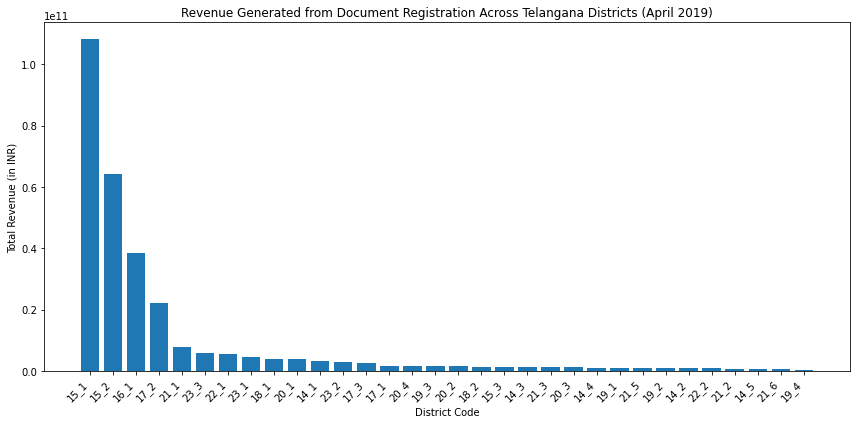

In [14]:
plt.figure(figsize=(12, 6))
plt.bar(district_revenue_sorted['dist_code'], district_revenue_sorted['documents_registered_rev'])
plt.xlabel('District Code')
plt.ylabel('Total Revenue (in INR)')
plt.title('Revenue Generated from Document Registration Across Telangana Districts (April 2019)')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()

# Display the plot
plt.show()

# How does the revenue generated from document registration compare to the revenue generated from e-stamp challans across districts?

In [69]:
# Group the data by district and calculate the total revenue for both document registration and e-stamp challans
district_revenue = df_stamps.groupby('dist_code')[['documents_registered_rev', 'estamps_challans_rev']].sum()

In [70]:
district_revenue

,documents_registered_rev,estamps_challans_rev
dist_code,,
14_1,3186731550,2236920432
14_2,978779682,709344353
14_3,1358262744,980926364
14_4,1126819540,830193698
14_5,722273314,517604092
15_1,108198682809,81336993463
15_2,64071382839,48819368222
15_3,1381189602,995418682
16_1,38396743983,28652397786


In [71]:
sorted_districts = district_revenue.sort_values(by='documents_registered_rev', ascending=False)


In [72]:
sorted_districts

,documents_registered_rev,estamps_challans_rev
dist_code,,
15_1,108198682809,81336993463
15_2,64071382839,48819368222
16_1,38396743983,28652397786
17_2,22024502771,16708219605
21_1,7927494100,5751116148
23_3,5973744502,4254388510
22_1,5606141586,4208231368
23_1,4521634367,3009297574
18_1,4046937361,3047094971


In [73]:
# Extract the top 10 districts for comparison (you can change the number as needed)
top_10_districts = sorted_districts.head(10)
top_10_districts

,documents_registered_rev,estamps_challans_rev
dist_code,,
15_1,108198682809,81336993463
15_2,64071382839,48819368222
16_1,38396743983,28652397786
17_2,22024502771,16708219605
21_1,7927494100,5751116148
23_3,5973744502,4254388510
22_1,5606141586,4208231368
23_1,4521634367,3009297574
18_1,4046937361,3047094971


<Figure size 864x432 with 0 Axes>

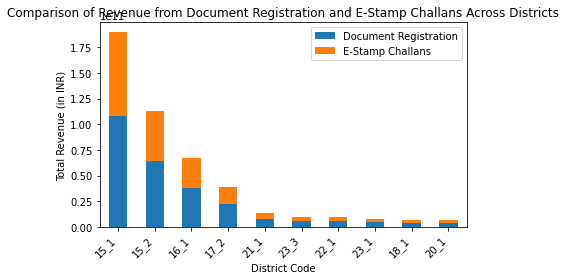

In [76]:
# Create a bar chart to compare revenue from document registration and e-stamp challans for the top 10 districts
plt.figure(figsize=(12, 6))
top_10_districts.plot(kind='bar', stacked=True)
plt.xlabel('District Code')
plt.ylabel('Total Revenue (in INR)')
plt.title('Comparison of Revenue from Document Registration and E-Stamp Challans Across Districts')
plt.legend(["Document Registration", "E-Stamp Challans"])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Display the plot
plt.show()

#  List down the top 5 districts where e-stamps revenue contributes significantly more to the revenue than the documents in FY 2022?

In [77]:
fy_2022_data = df_stamps[(df_stamps['Year'] == 2022)]

In [81]:
# Calculate the ratio of e-stamps revenue to document registration revenue for FY 2022
fy_2022_data['Revenue_Ratio']=fy_2022_data['estamps_challans_rev'] / fy_2022_data['documents_registered_rev']

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [82]:
fy_2022_data

,dist_code,month,documents_registered_cnt,documents_registered_rev,estamps_challans_cnt,estamps_challans_rev,Year,Month,Revenue_Ratio
1024,21_1,2022-01-01,4562,232096344,5460,264045590,2022,1,1.137655
1025,15_2,2022-01-01,15706,2169471006,17268,2665104212,2022,1,1.228458
1026,18_1,2022-01-01,4977,140585453,5888,161862023,2022,1,1.151343
1027,22_1,2022-01-01,4395,194046973,5230,218422134,2022,1,1.125615
1028,14_4,2022-01-01,2338,50976287,2465,52110450,2022,1,1.022249
...,...,...,...,...,...,...,...,...,...
1403,20_4,2022-12-01,1496,57282591,1479,57747406,2022,12,1.008114
1404,20_1,2022-12-01,3004,142858373,3035,142058913,2022,12,0.994404
1405,19_1,2022-12-01,1212,42679882,1271,43190728,2022,12,1.011969
1406,21_2,2022-12-01,887,20785376,890,19938358,2022,12,0.959249


In [83]:
# Sort the districts by the revenue ratio in descending order
sorted_districts = fy_2022_data.sort_values(by='Revenue_Ratio', ascending=False)


In [84]:
# Get the top 5 districts with the highest e-stamps-to-documents revenue ratio
top_5_districts = sorted_districts.head(5)

In [85]:
# Display the top 5 districts
print("Top 5 Districts with Significantly Higher E-Stamps Revenue than Documents Revenue (FY 2022):")
print(top_5_districts[['dist_code', 'Revenue_Ratio']])

Top 5 Districts with Significantly Higher E-Stamps Revenue than Documents Revenue (FY 2022):
     dist_code  Revenue_Ratio
1389      14_5       2.518235
1041      17_1       1.777764
1371      15_3       1.754159
1059      21_6       1.374078
1077      19_2       1.345585


In [7]:
df_transport=pd.read_csv('fact_transport.csv')
df_transport.head()

,dist_code,month,fuel_type_petrol,fuel_type_diesel,fuel_type_electric,fuel_type_others,vehicleClass_MotorCycle,vehicleClass_MotorCar,vehicleClass_AutoRickshaw,vehicleClass_Agriculture,vehicleClass_others,seatCapacity_1_to_3,seatCapacity_4_to_6,seatCapacity_above_6,Brand_new_vehicles,Pre-owned_vehicles,category_Non-Transport,category_Transport
0,15_1,2019-04-01,17910,3011,76,22,15308,4429,0,4,1278,16110,4182,717,19542,1477,19856,1163
1,18_2,2019-04-01,3066,306,6,0,2995,142,49,64,128,3156,189,33,3322,56,3203,175
2,20_3,2019-04-01,1577,215,0,0,1546,79,29,21,117,1683,104,5,1751,41,1648,144
3,21_3,2019-04-01,1961,281,2,0,1939,72,72,48,113,2082,146,16,2209,35,2075,169
4,21_7,2019-04-01,1552,309,0,0,1512,76,69,109,95,1696,145,20,1820,41,1701,160


In [8]:
df_tsipass=pd.read_csv('fact_TS_iPASS.csv')
df_tsipass.head()

,dist_code,month,sector,investment in cr,number_of_employees
0,14_1,01-04-2019,Engineering,2.3200,15
1,19_1,01-04-2019,Engineering,0.6250,13
2,20_3,01-04-2019,Wood and Leather,0.2000,8
3,20_3,01-04-2019,Textiles,0.2675,27
4,21_5,01-04-2019,Electrical and Electronic Products,0.1200,5


TypeError: 'Series' objects are mutable, thus they cannot be hashed

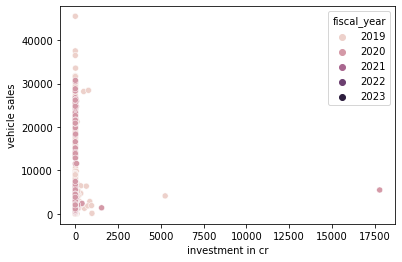

In [39]:
# Step 1: Load and Prepare Data

import pandas as pd

# Load relevant data into pandas DataFrames
df_iPASS = pd.read_csv('fact_TS_iPASS.csv')
df_transport = pd.read_csv('fact_transport.csv')

# Step 2: Create Fiscal Year Column

# Assuming you have a 'month' column in your data
df_iPASS['fiscal_year'] = pd.to_datetime(df_iPASS['month']).dt.year

df_transport['vehicle sales'] = df_transport['fuel_type_diesel'] + \
                            df_transport['fuel_type_electric'] + \
                            df_transport['fuel_type_others'] + \
                            df_transport['fuel_type_petrol']

# Step 3: Calculate Measures

# Calculate total investments, vehicle sales, and stamp revenue
total_investments_2021 = df_iPASS[df_iPASS['fiscal_year'] == 2021]['investment in cr'].sum()
total_investments_2022 = df_iPASS[df_iPASS['fiscal_year'] == 2022]['investment in cr'].sum()

# Similarly, calculate total vehicle sales and stamp revenue for 2021 and 2022

# Step 4: Analyze and Compare

# Compare the values for investments, vehicle sales, and stamp revenue for 2021 and 2022

# Step 5: Visualize Data

import matplotlib.pyplot as plt

# Create visualizations (e.g., bar charts, line plots) to compare the variables

# Step 6: Analyze Relationships

import seaborn as sns

# Use scatter plots or correlation plots to visually inspect relationships
sns.scatterplot(data=df_iPASS, x='investment in cr', y=df_transport['vehicle sales'], hue='fiscal_year')

# Step 7: Provide Insights

# Based on your analysis, provide insights into the relationships you observe

# Optional: Calculate Correlation Coefficients

correlation_2021 = df_iPASS[df_iPASS['fiscal_year'] == 2021][['investment in cr', df_transport['vehicle sales']]].corr()
correlation_2022 = df_iPASS[df_iPASS['fiscal_year'] == 2022][['investment in cr', df_transport['vehicle sales']]].corr()

print("Correlation for 2021:")
print(correlation_2021)

print("Correlation for 2022:")
print(correlation_2022)


In [112]:
df_transport.columns

Index(['dist_code', 'month', 'fuel_type_petrol', 'fuel_type_diesel',
       'fuel_type_electric', 'fuel_type_others', 'vehicleClass_MotorCycle',
       'vehicleClass_MotorCar', 'vehicleClass_AutoRickshaw',
       'vehicleClass_Agriculture', 'vehicleClass_others',
       'seatCapacity_1_to_3', 'seatCapacity_4_to_6', 'seatCapacity_above_6',
       'Brand_new_vehicles', 'Pre-owned_vehicles', 'category_Non-Transport',
       'category_Transport'],
      dtype='object')

In [103]:
df_transport['vehicle sales'] = df_transport['fuel_type_diesel'] + \
                            df_transport['fuel_type_electric'] + \
                            df_transport['fuel_type_others'] + \
                            df_transport['fuel_type_petrol']

In [124]:
df_transport.head()

,dist_code,month,fuel_type_petrol,fuel_type_diesel,fuel_type_electric,fuel_type_others,vehicleClass_MotorCycle,vehicleClass_MotorCar,vehicleClass_AutoRickshaw,vehicleClass_Agriculture,vehicleClass_others,seatCapacity_1_to_3,seatCapacity_4_to_6,seatCapacity_above_6,Brand_new_vehicles,Pre-owned_vehicles,category_Non-Transport,category_Transport,vehicle sales
0,15_1,2019-04-01,17910,3011,76,22,15308,4429,0,4,1278,16110,4182,717,19542,1477,19856,1163,21019
1,18_2,2019-04-01,3066,306,6,0,2995,142,49,64,128,3156,189,33,3322,56,3203,175,3378
2,20_3,2019-04-01,1577,215,0,0,1546,79,29,21,117,1683,104,5,1751,41,1648,144,1792
3,21_3,2019-04-01,1961,281,2,0,1939,72,72,48,113,2082,146,16,2209,35,2075,169,2244
4,21_7,2019-04-01,1552,309,0,0,1512,76,69,109,95,1696,145,20,1820,41,1701,160,1861


In [123]:
df_iPASS.head()

,dist_code,month,sector,investment in cr,number_of_employees,fiscal_year
0,14_1,01-04-2019,Engineering,2.3200,15,2019
1,19_1,01-04-2019,Engineering,0.6250,13,2019
2,20_3,01-04-2019,Wood and Leather,0.2000,8,2019
3,20_3,01-04-2019,Textiles,0.2675,27,2019
4,21_5,01-04-2019,Electrical and Electronic Products,0.1200,5,2019


In [137]:
df_stamps['total_stamp_revenue']=df_stamps['documents_registered_rev']+df_stamps['estamps_challans_rev']

In [41]:
df_iPASS.corr()

,investment in cr,number_of_employees,fiscal_year
investment in cr,1.000000,0.301429,-0.005366
number_of_employees,0.301429,1.000000,-0.029720
fiscal_year,-0.005366,-0.029720,1.000000


In [44]:
df_transport.head()

,dist_code,month,fuel_type_petrol,fuel_type_diesel,fuel_type_electric,fuel_type_others,vehicleClass_MotorCycle,vehicleClass_MotorCar,vehicleClass_AutoRickshaw,vehicleClass_Agriculture,vehicleClass_others,seatCapacity_1_to_3,seatCapacity_4_to_6,seatCapacity_above_6,Brand_new_vehicles,Pre-owned_vehicles,category_Non-Transport,category_Transport,vehicle sales
0,15_1,2019-04-01,17910,3011,76,22,15308,4429,0,4,1278,16110,4182,717,19542,1477,19856,1163,21019
1,18_2,2019-04-01,3066,306,6,0,2995,142,49,64,128,3156,189,33,3322,56,3203,175,3378
2,20_3,2019-04-01,1577,215,0,0,1546,79,29,21,117,1683,104,5,1751,41,1648,144,1792
3,21_3,2019-04-01,1961,281,2,0,1939,72,72,48,113,2082,146,16,2209,35,2075,169,2244
4,21_7,2019-04-01,1552,309,0,0,1512,76,69,109,95,1696,145,20,1820,41,1701,160,1861


In [75]:
merged_data = pd.merge(df_districts, df_transport, on='dist_code')


In [76]:
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1440 entries, 0 to 1439
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   dist_code                  1440 non-null   object
 1   district                   1440 non-null   object
 2   month                      1440 non-null   object
 3   fuel_type_petrol           1440 non-null   int64 
 4   fuel_type_diesel           1440 non-null   int64 
 5   fuel_type_electric         1440 non-null   int64 
 6   fuel_type_others           1440 non-null   int64 
 7   vehicleClass_MotorCycle    1440 non-null   int64 
 8   vehicleClass_MotorCar      1440 non-null   int64 
 9   vehicleClass_AutoRickshaw  1440 non-null   int64 
 10  vehicleClass_Agriculture   1440 non-null   int64 
 11  vehicleClass_others        1440 non-null   int64 
 12  seatCapacity_1_to_3        1440 non-null   int64 
 13  seatCapacity_4_to_6        1440 non-null   int64 
 14  seatCapa

In [86]:
df_stamps['total_stamp_revenue']=df_stamps['documents_registered_rev']+df_stamps['estamps_challans_rev']

In [87]:
df_transport['total_vehicle_sales']=df_transport['fuel_type_petrol']+df_transport['fuel_type_diesel']+df_transport['fuel_type_electric']+df_transport['fuel_type_others']

In [88]:
df_transport=pd.read_csv('fact_transport.csv')

In [89]:
merged_data = pd.merge(merged_data, df_transport, on=['dist_code', 'month'])


In [90]:
merged_data = pd.merge(merged_data, df_stamps, on=['dist_code', 'month'])

In [91]:
merged_data.columns

Index(['dist_code', 'district', 'month', 'fuel_type_petrol_x',
       'fuel_type_diesel_x', 'fuel_type_electric_x', 'fuel_type_others_x',
       'vehicleClass_MotorCycle_x', 'vehicleClass_MotorCar_x',
       'vehicleClass_AutoRickshaw_x', 'vehicleClass_Agriculture_x',
       'vehicleClass_others_x', 'seatCapacity_1_to_3_x',
       'seatCapacity_4_to_6_x', 'seatCapacity_above_6_x',
       'Brand_new_vehicles_x', 'Pre-owned_vehicles_x',
       'category_Non-Transport_x', 'category_Transport_x',
       'total_vehicle_sales', 'fuel_type_petrol_y', 'fuel_type_diesel_y',
       'fuel_type_electric_y', 'fuel_type_others_y',
       'vehicleClass_MotorCycle_y', 'vehicleClass_MotorCar_y',
       'vehicleClass_AutoRickshaw_y', 'vehicleClass_Agriculture_y',
       'vehicleClass_others_y', 'seatCapacity_1_to_3_y',
       'seatCapacity_4_to_6_y', 'seatCapacity_above_6_y',
       'Brand_new_vehicles_y', 'Pre-owned_vehicles_y',
       'category_Non-Transport_y', 'category_Transport_y',
       'documen

In [92]:
df_stamps.columns

Index(['dist_code', 'month', 'documents_registered_cnt',
       'documents_registered_rev', 'estamps_challans_cnt',
       'estamps_challans_rev', 'total_stamp_revenue'],
      dtype='object')

In [98]:
merged_data.columns

Index(['dist_code', 'district', 'month', 'fuel_type_petrol_x',
       'fuel_type_diesel_x', 'fuel_type_electric_x', 'fuel_type_others_x',
       'vehicleClass_MotorCycle_x', 'vehicleClass_MotorCar_x',
       'vehicleClass_AutoRickshaw_x', 'vehicleClass_Agriculture_x',
       'vehicleClass_others_x', 'seatCapacity_1_to_3_x',
       'seatCapacity_4_to_6_x', 'seatCapacity_above_6_x',
       'Brand_new_vehicles_x', 'Pre-owned_vehicles_x',
       'category_Non-Transport_x', 'category_Transport_x',
       'total_vehicle_sales', 'fuel_type_petrol_y', 'fuel_type_diesel_y',
       'fuel_type_electric_y', 'fuel_type_others_y',
       'vehicleClass_MotorCycle_y', 'vehicleClass_MotorCar_y',
       'vehicleClass_AutoRickshaw_y', 'vehicleClass_Agriculture_y',
       'vehicleClass_others_y', 'seatCapacity_1_to_3_y',
       'seatCapacity_4_to_6_y', 'seatCapacity_above_6_y',
       'Brand_new_vehicles_y', 'Pre-owned_vehicles_y',
       'category_Non-Transport_y', 'category_Transport_y',
       'documen

In [93]:
grouped_data = merged_data.groupby('district')

In [95]:
grouped_data.head()

,dist_code,district,month,fuel_type_petrol_x,fuel_type_diesel_x,fuel_type_electric_x,fuel_type_others_x,vehicleClass_MotorCycle_x,vehicleClass_MotorCar_x,vehicleClass_AutoRickshaw_x,...,seatCapacity_above_6,Brand_new_vehicles,Pre-owned_vehicles,category_Non-Transport,category_Transport,documents_registered_cnt_y,documents_registered_rev_y,estamps_challans_cnt_y,estamps_challans_rev_y,total_stamp_revenue_y
0,19_1,Adilabad,2019-04-01,1758,326,0,2,1697,116,77,...,79,2061,25,1832,254,1043,12672655,0,0,12672655
1,19_1,Adilabad,2019-05-01,1870,190,0,9,1823,96,71,...,27,2040,29,1926,143,1092,15177385,0,0,15177385
2,19_1,Adilabad,2019-06-01,1384,243,0,2,1352,105,93,...,44,1599,30,1469,160,824,11443194,0,0,11443194
3,19_1,Adilabad,2019-07-01,1264,197,0,9,1230,84,72,...,20,1455,15,1328,142,1186,17853370,0,0,17853370
4,19_1,Adilabad,2019-08-01,1137,209,1,4,1103,89,71,...,25,1330,21,1203,148,1124,14955291,0,0,14955291
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1316,23_3,Yadadri Bhuvanagiri,2019-04-01,2468,470,2,12,2398,198,56,...,37,2899,53,2690,262,7413,113680902,0,0,113680902
1317,23_3,Yadadri Bhuvanagiri,2019-05-01,2404,595,0,16,2321,231,53,...,35,2942,73,2709,306,8787,161615746,0,0,161615746
1318,23_3,Yadadri Bhuvanagiri,2019-06-01,2257,652,2,14,2195,188,65,...,70,2855,70,2534,391,9280,106077226,0,0,106077226
1319,23_3,Yadadri Bhuvanagiri,2019-07-01,2363,437,0,72,2286,187,137,...,48,2805,67,2527,345,9448,134999011,0,0,134999011


In [94]:
agg_data = grouped_data.agg({
    'investment in cr': 'sum',
    'total_stamp_revenue': 'sum',
    'total_vehicle_sales': 'sum'
})

SpecificationError: Column(s) ['investment in cr', 'total_stamp_revenue'] do not exist